In [113]:
import os
import cv2
import time
import numpy as np
from tqdm import tqdm
import psycopg2
from deepface import DeepFace
import matplotlib.pyplot as plt

In [114]:
instances = []
for path, name, files in os.walk('/home/usuario/Escritorio/facial_recognition_spoofing/images'):
    for file in files:
        img_path = f"{path}/{file}"
        if ".jpg" not in img_path:
            continue
        objs = DeepFace.represent(
            img_path=img_path,
            model_name="ArcFace",
        )
        for obj in objs:
            embedding = obj["embedding"]
            instances.append((file, embedding))

In [115]:
# embedding de 512 dimensiones
print(len(instances[0][1]))
print(len(instances))

512
2


In [116]:
target_size = 1000

for i in range(len(instances), target_size):
    img_name = f"synthetic_{i}.jpg"
    embedding = np.random.uniform(-5, +5, 512).tolist()
    instances.append((img_path, embedding))

In [117]:
conn = psycopg2.connect(
    host="localhost",
    user="postgres",
    password="postgres",
    port="5432",
    database="db_faces"
)

In [118]:
cursor = conn.cursor()

In [119]:
sql = """ INSERT INTO users (name, embedding) values (%s, %s)"""

for idx, (img_path, embedding) in tqdm(enumerate(instances)):
    try:
        cursor.execute(sql, (img_path, str(embedding)))
    except Exception as e:
        conn.rollback()
        print(f"Error: {e}")
        break

1000it [00:00, 2590.26it/s]


In [120]:
conn.commit()

In [139]:
target_img_path = "/home/usuario/Escritorio/facial_recognition_spoofing/img-test/2026-05-14-153429.jpg"

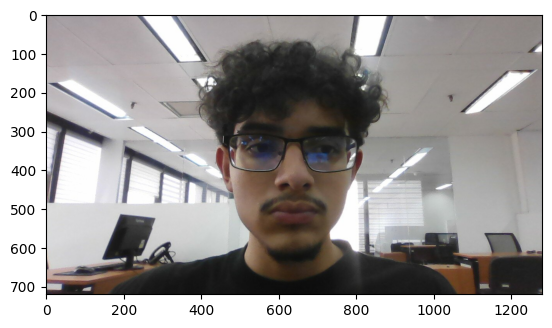

In [140]:
target_img = cv2.imread(target_img_path)
plt.imshow(target_img[:,:,::-1])

In [142]:
objs = DeepFace.represent(
    img_path=target_img_path,
    model_name="ArcFace",
    enforce_detection=False
)

In [143]:
target_embedding = objs[0]['embedding']

In [144]:
vector_literal = '[' + ','.join(str(x) for x in target_embedding) + ']'
try: 
    cursor.execute("""
    SELECT * FROM (
        SELECT name, embedding <-> %s::vector AS distance
        FROM users
    ) a
    WHERE distance < 10
    ORDER BY distance ASC
    LIMIT 1
    """, (vector_literal,))
    results = cursor.fetchall()
except Exception as e:
    conn.rollback()
    print(f"Error: {e}")

In [145]:
print(results)

[('adrian.jpg', 6.333539591325123)]


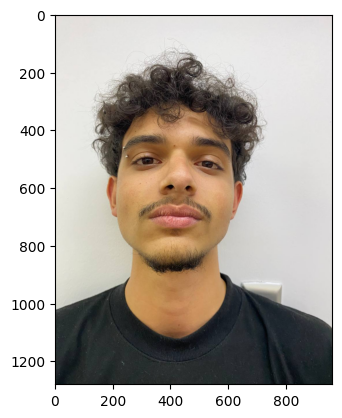

In [147]:
source_img = cv2.imread(f"/home/usuario/Escritorio/facial_recognition_spoofing/images/{results[0][0]}")
plt.imshow(source_img[:,:,::-1])
plt.show()